# Hyperbolic parametrization of exceedance probabilities

- **Summary**: This document discusses the hyperbolic parametrization of exceedance probabilities (based on the method of conditional moments) introduced in [Fan et al. (2018)](https://www.dcp-3.org/sites/default/files/chapters/DCP3%20Volume%209_Ch%2018.pdf), and replicates the benchmark results of [Bernstein et al. (2022)](https://doi.org/10.1126/sciadv.abl4183).

- **Viral Zoonotic Outbreak Data:** [Bernstein et al. (2022)](https://doi.org/10.1126/sciadv.abl4183).

- **Note:** While Bernstein et al. performed hyperbolic parametrization on historical outbreak data, Fan et al. performed hyperbolic parametrization on [flu pandemic severities simulated by *AIR Worldwide* (2014)](https://www.air-worldwide.com/SiteAssets/Publications/Brochures/documents/The-AIR-Pandemic-Flu-Model). (The risk modeling and data analytics company *AIR Worldwide* is now known as *Verisk Extreme Event Solutions*.)

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 10, 2024

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.optimize import minimize

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
# Set filepaths
rawdata_dir = Path("../../data/raw").resolve()
cleandata_dir = Path("../../data/clean").resolve()
figdir = Path("../../output/exceedance_figures").resolve()

## 0. Prepare viral zoonotic outbreak data

In [2]:
## Obtain outbreak data from Table 1 on p.3 of Bernstein et al. (2022)
year_start = [1918, 1951, 1956, 1957, 1957, 1958, 1960, 1963, 1967, 1968, 
              1969, 1969, 1970, 1976, 1977, 1980, 1980, 1989, 1993, 1995, 
              1998, 1999, 2002, 2004, 2008, 2009, 2012, 2015, 2020]

disease = ['Spanish Influenza', 'Hantaan virus', 'South American hantaviruses', 
           'Kyasanur forest disease', 'H2N2 influenza', 'Junin virus', 
           'Lacrosse virus', 'Machupo virus', 'Marburg virus', 
           'H3N2 influenza', 'Lassa fever', 'Venezuelan equine encephalitis', 
           'Monkeypox', 'Ebola', 'Rift valley fever', 
           'HIV', 'Puumala virus', 'Guanrito virus', 
           'Sin nombre', 'Andes', 'Nipah', 
           'West Nile', 'SARS', 'Chikungunya', 
           'H1N1 influenza', 'Severe fever thrombocytopenia syndrome', 'MERS', 
           'Zika', 'COVID-19']

death = [50000000, 46430, 1990, 1000, 1100000, 5900, 300, 290, 370, 1000000, 
         250000, 300, 5000, 12930, 3000, 10700000, 10, 140, 260, 130, 
         200, 2330, 770, 35000, 284000, 370, 860, 50, 4000000]

pop = [1830000000, 2584034261, 2822443282, 2873306090, 2873306090, 2925686705, 
       3034949748, 3211001009, 3478769962, 3551599127, 3625680627, 3625680627, 
       3700437046, 4154666864, 4229506060, 4458003514, 4458003514, 5237441558, 
       5581597546, 5744212979, 5984793942, 6064239055, 6301773188, 6461159389, 
       6789088686, 6872767093, 7125828059, 7379797139, 7794798739]

## Create dataframe for 29 viral zoonotic outbreaks since 1900
df_viral_zoonotic = pd.DataFrame({
    'year_start': year_start,
    'disease': disease,
    'death': death,
    'pop': pop
})

## Calculate severity in SMU (deaths per 10,000 people)
df_viral_zoonotic['severity_smu'] = (df_viral_zoonotic['death'] / 
                                     df_viral_zoonotic['pop']) * 10**4


In [3]:
## Display novel viral zoonotic outbreak data
df_viral_zoonotic

## Save data
df_viral_zoonotic.to_excel(rawdata_dir / "novel_viral_outbreaks_bernstein_240828.xlsx", index=False)


,year_start,disease,death,pop,severity_smu
0,1918,Spanish Influenza,50000000,1830000000,273.224044
1,1951,Hantaan virus,46430,2584034261,0.179680
2,1956,South American hantaviruses,1990,2822443282,0.007051
3,1957,Kyasanur forest disease,1000,2873306090,0.003480
4,1957,H2N2 influenza,1100000,2873306090,3.828343
5,1958,Junin virus,5900,2925686705,0.020166
6,1960,Lacrosse virus,300,3034949748,0.000988
7,1963,Machupo virus,290,3211001009,0.000903
8,1967,Marburg virus,370,3478769962,0.001064
9,1968,H3N2 influenza,1000000,3551599127,2.815633


**Note:** The COVID-19 deaths is only updated to July 2021. Severity is measured in standardized mortality units (SMUs), or deaths per 10,000 people.

## 1. Hyperbolic parametrization

**Introduction:** [Fan et al. (2018)](https://www.dcp-3.org/sites/default/files/chapters/DCP3%20Volume%209_Ch%2018.pdf) defined $s$ as the severity of flu pandemics, and $r(s)$ as the probability that a pandemic with severity greater than $s$ is observed in a given year, or $\Pr(S>s)$. They provided the parametrization for the exceedance function

<p align="center">
\[
r(s) = [1+m(1-f)s]^{-[1+1/(1-f)]},
\]
</p>

where a smaller $f$ represents a fatter tail for the distribution. The expected severity of all pandemics in a given year $\mathbb{E}(s_a)$, or first moment, can be represented as (check this via integration by parts)

<p align="center">
\[
\mathbb{E}(s_a) = \int_0^\infty r(s) ds = \frac{1}{m} = p_a \mu_a.
\]
</p>

So using $p_a$, the probability a pandemic arriving within the year, and $\mu_a$, the mean severity of flu pandemics conditional on arrival, we can calibrate the parameter $m = 1/ (p_a \mu_a)$. We then select a severity threshold $\tau_x$, above which pandemics are considered to be extreme. We then use the probability an extreme flu pandemic arriving within the year, $p_x$, and the mean severity of extreme flu pandemics conditional on arrival, $\mu_x$, to calibrate $f$:

<p align="center">
\[
\mathbb{E}(s_x) = \int_{\tau_x}^\infty r(s) ds = p_x \mu_x.
\]
</p>

To summarize the process, first estimate $p_a$ and $\mu_a$ to estimate $m$ using the first moment, then decide on a threshold $\tau_x$ for extreme severities to calculate $p_x$ and $\mu_x$ to estimate $f$, the fatness of the tail, using the first moment conditional upon threshold-exceedance.

## 2. Bernstein et al. (2022) replication

**Note:** In their benchmark estimation, Bernstein et al. used rounded estimates of the parameter $m$ and the expected annual severity of extreme outbreaks $\mathbb{E}(s_x)$ to calibrate a value for $f$, which is also rounded to **two decimal places**. 


In [4]:
## Define extreme severity threshold 'thresh'
thresh = 10  ## Set extreme severity threshold to 10 SMU

## Define arrival and mean severity of all outbreaks
p_a = 28 / 70  ## 28 outbreaks in the past 70 years
mu_a = np.mean(df_viral_zoonotic['severity_smu']) ## mean severity of all outbreaks

## Define arrival and mean severity of extreme outbreaks
p_x = 2 / 100  ## 2 extreme outbreaks (1918 flu pandemic & HIV) in 100 years
mu_x = np.mean(df_viral_zoonotic['severity_smu'][
    df_viral_zoonotic['severity_smu'] >= thresh])  ## mean severity of extreme outbreaks


In [5]:
## Find expected annual SMUs of all and extreme outbreaks
s_a = round(p_a * mu_a, 2)  ## expected annual severity of all outbreaks
s_x = round(p_x * mu_x, 2)  ## expected annual severity of extreme outbreaks


In [6]:
## Calibrate 'm'
m = round(1/(s_a), 2)  ## round 'm' to 2 decimals


In [7]:
## Define function to calibrate 'f' with conditional first moment
def calibrate_hyperbolic_f(m, thresh, s_x):
    """
    Calibrate the parameter 'f' for a hyperbolic function from Fan et al. 
    (2018) based on the first moment conditional on exceedance.

    Parameters:
    - m: float, parameter of the hyperbolic model.
    - thresh: float, threshold value for extreme severities.
    - s_x: float, annual expected extreme severity.

    Returns:
    - f_opt: float, the optimal value of 'f' that minimizes the difference 
      between the integral and the conditional first moment.
    """
    
    ## Define integrand for hyperbolic exceedance
    def integrand(s, m, f):
        return (1 + m * (1 - f) * s) ** (-1 - 1 / (1 - f))
    
    ## Define the objective function to minimize
    def objective(f, m, s_x):
        integral, _ = quad(integrand, thresh, np.inf, args=(m, f))
        return (s_x - integral) ** 2
    
    ## Set bounds for 'f'
    bounds = [(-20, -1)]
    
    ## Minimize difference between integral and conditional moment
    ## x0 is the initial guess for 'f'
    result = minimize(objective, x0=-2, args=(m, s_x), bounds=bounds)
    
    ## Print result
    if result.success:
        if result.fun < 1e-08:
            print("Convergence succeeded! :)")
            print(f"Minimized cost value: {result.fun}")
            print(f"Optimal value of f: {round(result.x[0], 2)}")
        else:
            print("Convergence failed. :(")
            print(f"Minimized cost value: {result.fun}")
    else:
        print("Optimization failed. :(")
        print("Objective function value: NA")
    
    ## Return optimal value of 'f'
    f_opt = result.x[0] if result.success else None
    return f_opt

## Example usage:
## m = 0.23
## thresh = 10
## s_x = 2.97
## f = calibrate_hyperbolic_f(m, thresh, s_x)    


In [8]:
## Calibrate 'f'
f = calibrate_hyperbolic_f(m, thresh, s_x) 
f = round(f, 2)  ## round 'f' to 2 decimals


Convergence succeeded! :)
Minimized cost value: 1.079544978414333e-09
Optimal value of f: -6.68


In [9]:
print(f'Result: m = {m}, f = {f}')


Result: m = 0.23, f = -6.68


**Note:** Our result matches the benchmark result of Bernstein et al. displayed in the first row of Table S1 in their supplementary information. They also have $m=0.23$ and $f=-6.68$.

## 3. Visualize viral zoonotic exceedance 

In [10]:
## Calculate parametrized exceedance probabilities for historical obs
severity = df_viral_zoonotic['severity_smu']
exceedance = [(1 + m * (1 - f) * s)**(-1 - 1/(1 - f)) for s in severity]

## Create dataframe on exceedance probabilities
df_bernstein = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index
df_bernstein = df_bernstein.sort_values(by='severity', ascending=True)
df_bernstein = df_bernstein.reset_index(drop=True)


<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Severity (SMU = deaths per 10,000 people)')

Text(0, 0.5, 'Annual exceedance probability (log scale)')

(0.0001, 1.0)

(0.0, 300.0)

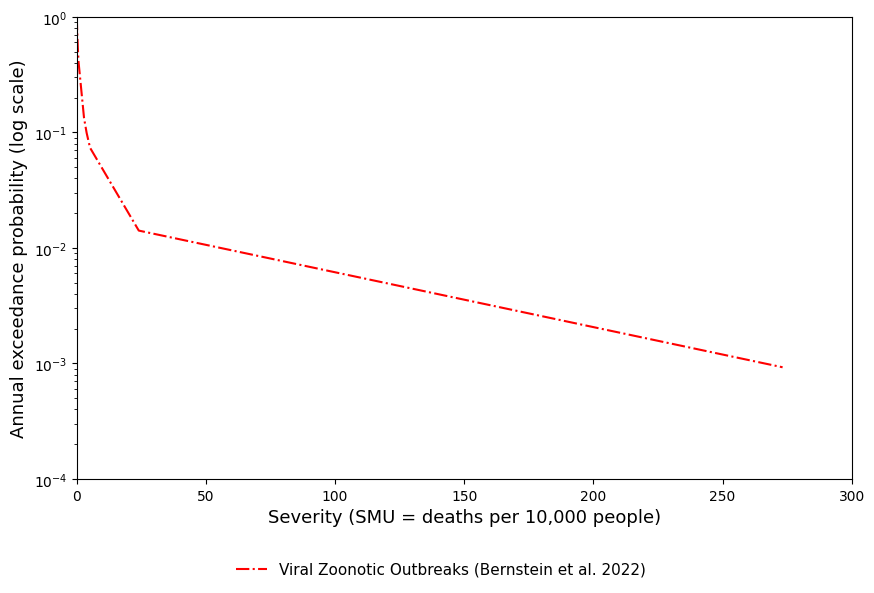

In [13]:
## Visualize viral zoonotic exceedance
plt.figure(figsize=(10, 6))
plt.plot(df_bernstein['severity'], df_bernstein['exceedance'], color='red', linestyle='-.', 
         label='Viral Zoonotic Outbreaks (Bernstein et al. 2022)')

## Add labels and title
plt.xlabel('Severity (SMU = deaths per 10,000 people)', fontsize=13)
plt.ylabel('Annual exceedance probability (log scale)', fontsize=13)
# plt.title('Exceedance Probability of Novel Viral Zoonotic Outbreaks', fontsize=15)

## Set y-axis to log scale with limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis limits
plt.xlim(0, 300)

## Adding legend below the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=1, frameon=False, fontsize=11)

## Save graph
plt.savefig(figdir / '02_bernstein_exceedance.jpg', dpi=400, bbox_inches = 'tight')

## Display graph
plt.show()
